# Day 56: KNN — Distance-Based Intuition
**Phase 4 · Machine Learning** | Dataset: FC Lahore Lions players (synthetic, seed = 42)

## Objective
By the end of this notebook I should be able to:
- Explain KNN as **"find the K closest players and take a majority vote"**
- Calculate **Euclidean distance** by hand for a 2D example, then check it with NumPy
- Explain why KNN has **no real training phase** (it just remembers the data)
- Show how **K** changes the model (train vs test accuracy)
- Show why **feature scaling is critical** for KNN, using the same data unscaled vs scaled

## Imports

In [1]:
# numpy and pandas for data
import numpy as np
import pandas as pd

# Counter helps count votes
from collections import Counter

# matplotlib for charts
import matplotlib.pyplot as plt

# KNN model, scaler and splitter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

plt.rcParams["axes.grid"] = True

## Theory
- **KNN (K-Nearest Neighbours)** predicts by asking: *who are the K most similar training examples, and what class did most of them have?*
- **No training phase:** `.fit()` just stores the training data. All the work happens at prediction time. This is why KNN is called "lazy".
- **Distance = similarity.** The most common measure is **Euclidean distance**: `sqrt((x1 - x2)² + (y1 - y2)²)` for 2 features (add one more squared term per extra feature).
- **Majority vote:** with K = 5, if 3 of the 5 nearest players are wingers, predict winger. Use an **odd K** for two classes to avoid ties.
- **Effect of K:**
  - K = 1: follows every single point, very wiggly boundary (**overfit risk**)
  - Large K (like 100): very smooth boundary, ignores local detail (**underfit risk**)
- **Feature scaling is critical:** distance adds up differences across features. A feature measured in thousands (minutes played) drowns out a feature measured in tens (sprint speed). Scale first.

**Football picture:** to guess a new player's role, look at the 5 players in the squad who play most like him and go with what most of them are.

## Example 1: Distance and the Nearest-Neighbour Vote

In [2]:
# Synthetic data: 300 players. Target: is_winger (1 = winger, 0 = centre back)
rng = np.random.default_rng(42)                       # seed = 42 so results repeat
n_players = 300
is_winger = rng.integers(0, 2, size=n_players)

# Wingers are a bit faster on average. Minutes played has NO link to the role
# (I included it on purpose to show the scaling problem).
speed = np.where(is_winger == 1,
                 rng.normal(31.5, 1.8, n_players),
                 rng.normal(29.0, 1.8, n_players)).round(1)
minutes = rng.integers(500, 3001, size=n_players)

df = pd.DataFrame({
    "player_id": np.arange(1, n_players + 1),
    "sprint_speed_kmh": speed,
    "minutes_played": minutes,
    "is_winger": is_winger
})

# Save next to the notebook, then read it back
df.to_csv("day_56_fc_lahore_lions_players.csv", index=False)
df = pd.read_csv("day_56_fc_lahore_lions_players.csv")

print(df.head())
print("\nColumn ranges:")
print(df[["sprint_speed_kmh", "minutes_played"]].agg(["min", "max"]))

   player_id  sprint_speed_kmh  minutes_played  is_winger
0          1              31.0            2742          0
1          2              31.8            2433          1
2          3              31.2            2988          1
3          4              29.6            2639          0
4          5              32.5            1228          0

Column ranges:
     sprint_speed_kmh  minutes_played
min              24.4             508
max              36.7            2988


In [3]:
# Euclidean distance BY HAND for two players: (speed, minutes)
player_a = (31.0, 1200)
player_b = (29.5, 1500)

diff_speed = player_a[0] - player_b[0]        # 1.5 km/h apart
diff_minutes = player_a[1] - player_b[1]      # -300 minutes apart

distance = (diff_speed ** 2 + diff_minutes ** 2) ** 0.5    # square root of the sum of squares
print("By hand:", round(distance, 3))

# Check with NumPy - the answer must match
print("NumPy:  ", round(np.linalg.norm(np.array(player_a) - np.array(player_b)), 3))

# Notice: the speed gap adds 2.25, the minutes gap adds 90000. Minutes decides everything.
print("Speed part:", diff_speed ** 2, "| Minutes part:", diff_minutes ** 2)

By hand: 300.004
NumPy:   300.004
Speed part: 2.25 | Minutes part: 90000


In [4]:
# Split first (same rule as Day 49): features X, target y
X = df[["sprint_speed_kmh", "minutes_played"]]
y = df["is_winger"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train:", len(X_train), "| Test:", len(X_test))

Train: 225 | Test: 75


In [5]:
# KNN FROM SCRATCH for one new player: speed 31.0 km/h, 1500 minutes
new_player = np.array([31.0, 1500])

# Step 1: distance from the new player to EVERY training player
distances = np.sqrt(((X_train.values - new_player) ** 2).sum(axis=1))

# Step 2: positions of the 5 smallest distances
nearest = np.argsort(distances)[:5]

# Step 3: majority vote among their classes
votes = y_train.values[nearest]
print("Neighbour classes:", votes)
print("Vote result:", Counter(votes).most_common(1)[0][0])

Neighbour classes: [0 0 0 0 0]
Vote result: 0


In [6]:
# The same thing with sklearn. fit() only STORES the data - no learning happens.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("sklearn prediction:", knn.predict(pd.DataFrame([[31.0, 1500]], columns=X.columns))[0])

sklearn prediction: 0


## Example 2: Scaling and the Effect of K

### 2A. Unscaled data (the wrong way)

In [7]:
# KNN with K = 5 on the RAW features
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
print("Unscaled test accuracy:", round(knn_raw.score(X_test, y_test), 3))

Unscaled test accuracy: 0.453


### 2B. Scaled data (the right way)

In [8]:
# StandardScaler: (value - mean) / std for each column, so both features have a similar scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)     # learn mean/std from TRAIN only
X_test_s = scaler.transform(X_test)           # reuse the train mean/std on TEST (no leakage)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_s, y_train)
print("Scaled test accuracy:", round(knn_scaled.score(X_test_s, y_test), 3))

Scaled test accuracy: 0.76


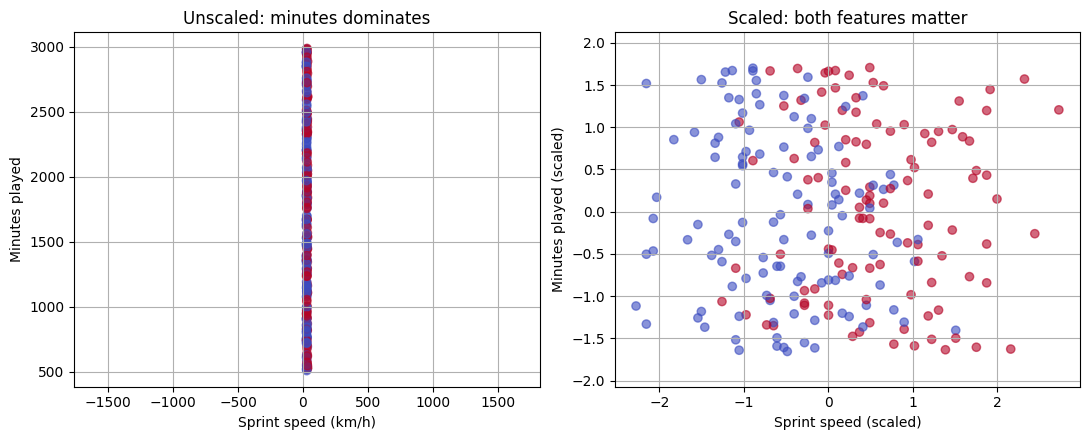

In [9]:
# Chart: what the distance calculation "sees" - unscaled (left) vs scaled (right)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Same units on both axes so the distances are drawn honestly
axes[0].scatter(X_train["sprint_speed_kmh"], X_train["minutes_played"],
                c=y_train, cmap="coolwarm", alpha=0.6)
axes[0].set_title("Unscaled: minutes dominates")
axes[0].set_xlabel("Sprint speed (km/h)")
axes[0].set_ylabel("Minutes played")
axes[0].set_aspect("equal", adjustable="datalim")

axes[1].scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap="coolwarm", alpha=0.6)
axes[1].set_title("Scaled: both features matter")
axes[1].set_xlabel("Sprint speed (scaled)")
axes[1].set_ylabel("Minutes played (scaled)")
axes[1].set_aspect("equal", adjustable="datalim")

plt.tight_layout()
plt.savefig("images/scaling_what_knn_sees.png", dpi=150, bbox_inches="tight")
plt.show()

### 2C. How K changes the model (scaled data)

In [10]:
# Train vs test accuracy for different K (odd values to avoid ties)
k_values = [1, 3, 5, 9, 15, 25, 51, 101]
train_scores, test_scores = [], []

print("   K | train acc | test acc")
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)
    tr = model.score(X_train_s, y_train)
    te = model.score(X_test_s, y_test)
    train_scores.append(tr)
    test_scores.append(te)
    print(f"{k:>4} | {tr:>9.3f} | {te:>8.3f}")

   K | train acc | test acc
   1 |     1.000 |    0.600
   3 |     0.809 |    0.747
   5 |     0.818 |    0.760
   9 |     0.791 |    0.747
  15 |     0.760 |    0.733
  25 |     0.742 |    0.720
  51 |     0.773 |    0.733
 101 |     0.756 |    0.760


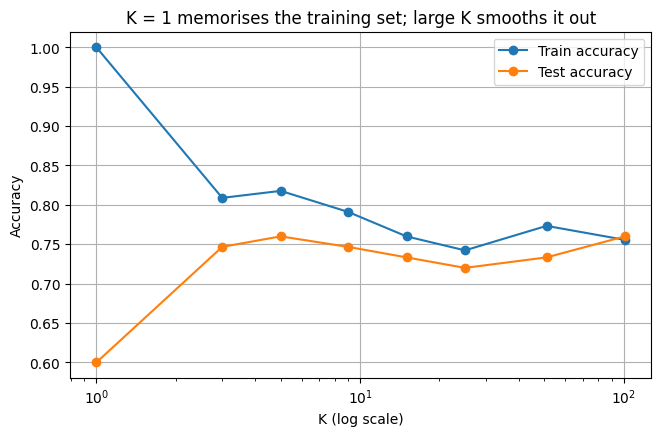

In [11]:
# Chart: accuracy against K (K on a log-style spacing by using the list position)
plt.figure(figsize=(7.5, 4.5))
plt.plot(k_values, train_scores, marker="o", label="Train accuracy")
plt.plot(k_values, test_scores, marker="o", label="Test accuracy")
plt.xscale("log")
plt.xlabel("K (log scale)")
plt.ylabel("Accuracy")
plt.title("K = 1 memorises the training set; large K smooths it out")
plt.legend()
plt.savefig("images/accuracy_vs_k.png", dpi=150, bbox_inches="tight")
plt.show()

## Practice Exercise
**Your turn (Practice).** New player `N = (30.0 km/h, 1250 minutes)`. Existing players:
- `A = (32.0, 1400)`, `B = (28.0, 1000)`, `C = (31.0, 1900)`

1. Work out the Euclidean distance from N to A, B and C **by hand** (unscaled).
2. Which player is the nearest neighbour?
3. Which feature mostly decided it? Why?

In [12]:
# Your attempt here

In [13]:
# Worked answer
new = np.array([30.0, 1250])
others = {"A": np.array([32.0, 1400]),
          "B": np.array([28.0, 1000]),
          "C": np.array([31.0, 1900])}

for name, point in others.items():
    d = np.sqrt(((new - point) ** 2).sum())        # Euclidean distance
    print(name, round(d, 2))
# The minutes gap (150, 250, 650) dwarfs the speed gap (2, 2, 1), so minutes decides.

A 150.01
B 250.01
C 650.0


## Mini Challenge
**Choose K the honest way.** Picking K by looking at the test score leaks information from the test set. Instead:
1. Split the **training** data again into a smaller train part and a validation part.
2. Scale using the smaller train part only.
3. Try odd K from 1 to 41 and keep the K with the best **validation** accuracy.
4. Retrain on the full scaled training set with that K and score the test set **once**.

In [14]:
# Mini Challenge solution
# 1. Split TRAIN into sub-train and validation (the test set is not touched)
X_sub, X_val, y_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

# 2. Scale using sub-train only
sub_scaler = StandardScaler().fit(X_sub)
X_sub_s = sub_scaler.transform(X_sub)
X_val_s = sub_scaler.transform(X_val)

# 3. Try odd K values, keep the best validation accuracy
best_k, best_val = None, 0
for k in range(1, 42, 2):
    val_acc = KNeighborsClassifier(n_neighbors=k).fit(X_sub_s, y_sub).score(X_val_s, y_val)
    if val_acc > best_val:                 # strictly better, so ties keep the smaller K
        best_k, best_val = k, val_acc
print("Best K on validation:", best_k, "| validation accuracy:", round(best_val, 3))

# 4. Retrain on the full scaled training set, score the test set once
final = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_s, y_train)
print("Test accuracy:", round(final.score(X_test_s, y_test), 3))

# Caution: the validation set is small (57 rows), so this K is a noisy choice.
# Cross-validation (Day 57) gives a steadier answer.

Best K on validation: 11 | validation accuracy: 0.754
Test accuracy: 0.747


## Summary
- KNN predicts by **majority vote of the K nearest training points**. `.fit()` only stores the data.
- Closeness is measured with **Euclidean distance**: `sqrt(sum((x1 - x2)²))`.
- **K = 1** memorises the training set (train accuracy 1.0, lower test accuracy). Larger K smooths the model.
- **Scaling is critical:** on the same data, unscaled KNN was no better than guessing while scaled KNN was clearly better.
- Choose K with a validation set, not the test set.
- **Next: Day 57 — KNN with sklearn + cross-validation for choosing K.**